#  library load

In [86]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Datasets load

In [87]:
 
df = pd.read_csv('HDHI Admission data.csv')
 

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15757 entries, 0 to 15756
Data columns (total 56 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   SNO                              15757 non-null  int64 
 1   MRD No.                          15757 non-null  object
 2   D.O.A                            15757 non-null  object
 3   D.O.D                            15757 non-null  object
 4   AGE                              15757 non-null  int64 
 5   GENDER                           15757 non-null  object
 6   RURAL                            15757 non-null  object
 7   TYPE OF ADMISSION-EMERGENCY/OPD  15757 non-null  object
 8   month year                       15757 non-null  object
 9   DURATION OF STAY                 15757 non-null  int64 
 10  duration of intensive unit stay  15757 non-null  int64 
 11  OUTCOME                          15757 non-null  object
 12  SMOKING                         

In [89]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
15752    False
15753    False
15754    False
15755    False
15756    False
Length: 15757, dtype: bool

#  Clean Column Names

In [90]:
 
df.columns = df.columns.str.strip()
df.head(10)

,SNO,MRD No.,D.O.A,D.O.D,AGE,GENDER,RURAL,TYPE OF ADMISSION-EMERGENCY/OPD,month year,DURATION OF STAY,...,CONGENITAL,UTI,NEURO CARDIOGENIC SYNCOPE,ORTHOSTATIC,INFECTIVE ENDOCARDITIS,DVT,CARDIOGENIC SHOCK,SHOCK,PULMONARY EMBOLISM,CHEST INFECTION
0,1,234735,4/1/2017,4/3/2017,81,M,R,E,Apr-17,3,...,0,0,0,0,0,0,0,0,0,0
1,2,234696,4/1/2017,4/5/2017,65,M,R,E,Apr-17,5,...,0,0,0,0,0,0,0,0,0,0
2,3,234882,4/1/2017,4/3/2017,53,M,U,E,Apr-17,3,...,0,0,0,0,0,0,0,0,0,0
3,4,234635,4/1/2017,4/8/2017,67,F,U,E,Apr-17,8,...,0,0,0,0,0,0,0,0,0,0
4,5,234486,4/1/2017,4/23/2017,60,F,U,E,Apr-17,23,...,0,0,0,0,0,0,0,0,0,0
5,6,234675,4/1/2017,4/10/2017,44,M,U,E,Apr-17,10,...,0,0,0,0,0,0,0,0,0,0
6,7,234563,4/1/2017,4/6/2017,56,F,U,E,Apr-17,6,...,0,0,0,0,0,0,0,0,0,0
7,8,208455,4/1/2017,4/13/2017,47,M,U,E,Apr-17,13,...,0,0,0,0,0,0,0,0,0,0
8,9,67070,4/1/2017,4/3/2017,65,F,U,E,Apr-17,3,...,0,0,0,0,0,0,0,1,0,0
9,10,153218,4/1/2017,4/3/2017,59,M,U,E,Apr-17,3,...,0,0,0,0,0,0,0,0,0,0


 # Date Parsing

In [91]:
df['D.O.A'] = pd.to_datetime(df['D.O.A'], dayfirst=True, errors='coerce')
df['D.O.D'] = pd.to_datetime(df['D.O.D'], dayfirst=True, errors='coerce')

# 3. Duration  collumn convert into number

In [92]:
 
df['DURATION OF STAY'] = pd.to_numeric(df['DURATION OF STAY'], errors='coerce')

In [93]:
df_clean = df.dropna(subset=['D.O.A', 'D.O.D'])
print(f"Final Data Size: {len(df_clean)}")
print(f"Data Lost: {len(df) - len(df_clean)} (Much better than 5500!)")

Final Data Size: 11040
Data Lost: 4717 (Much better than 5500!)


#   occupancy (Time Series)

In [94]:
 
start_date = df_clean['D.O.A'].min()
end_date = df_clean['D.O.D'].max()
all_dates = pd.date_range(start=start_date, end=end_date, freq='D')
occupancy_list = []
for current_date in all_dates:
     
    # (DOD > Date) 
    active = ((df_clean['D.O.A'] <= current_date) & (df_clean['D.O.D'] > current_date)).sum()
    occupancy_list.append(active)

In [95]:
df.isnull().sum()

SNO                                   0
MRD No.                               0
D.O.A                              3767
D.O.D                              3770
AGE                                   0
GENDER                                0
RURAL                                 0
TYPE OF ADMISSION-EMERGENCY/OPD       0
month year                            0
DURATION OF STAY                      0
duration of intensive unit stay       0
OUTCOME                               0
SMOKING                               0
ALCOHOL                               0
DM                                    0
HTN                                   0
CAD                                   0
PRIOR CMP                             0
CKD                                   0
HB                                  252
TLC                                 286
PLATELETS                           285
GLUCOSE                             863
UREA                                241
CREATININE                          247


In [96]:
 
final_df = pd.DataFrame({'Date': all_dates, 'Total_Occupancy': occupancy_list})
final_df.to_csv('processed_occupancy_v3.csv', index=False)

# visulization

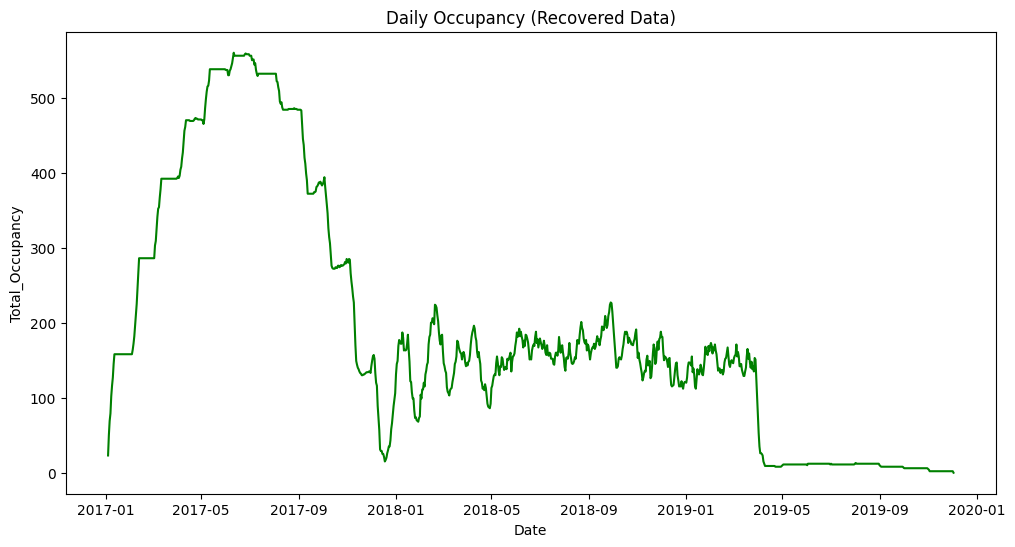

In [97]:
 
plt.figure(figsize=(12, 6))
sns.lineplot(data=final_df, x='Date', y='Total_Occupancy', color='green')
plt.title('Daily Occupancy (Recovered Data)')
plt.show()

# Feature Engineering

In [98]:
df = pd.read_csv('processed_occupancy_v3.csv')
df['Date'] = pd.to_datetime(df['Date'])

# calender

In [99]:
df['Day_of_Week'] = df['Date'].dt.dayofweek

# 1 = January, 12 = December
df['Month'] = df['Date'].dt.month

#  (1-31)
df['Day_of_Month'] = df['Date'].dt.day

# before  1 and 7 days paitent pattern

In [100]:
df['Lag_1'] = df['Total_Occupancy'].shift(1)
 
df['Lag_7'] = df['Total_Occupancy'].shift(7)

# last 7 days paitent mean

In [101]:
 
df['Rolling_Mean_7'] = df['Total_Occupancy'].rolling(window=7).mean()


In [102]:
 
df_ml = df.dropna()


In [103]:
 
 
print(df_ml.head())


         Date  Total_Occupancy  Day_of_Week  Month  Day_of_Month  Lag_1  \
7  2017-01-11              145            2      1            11  127.0   
8  2017-01-12              158            3      1            12  145.0   
9  2017-01-13              158            4      1            13  158.0   
10 2017-01-14              158            5      1            14  158.0   
11 2017-01-15              158            6      1            15  158.0   

    Lag_7  Rolling_Mean_7  
7    23.0       98.285714  
8    50.0      113.714286  
9    69.0      126.428571  
10   79.0      137.714286  
11  102.0      145.714286  


# Correlation Heatmap

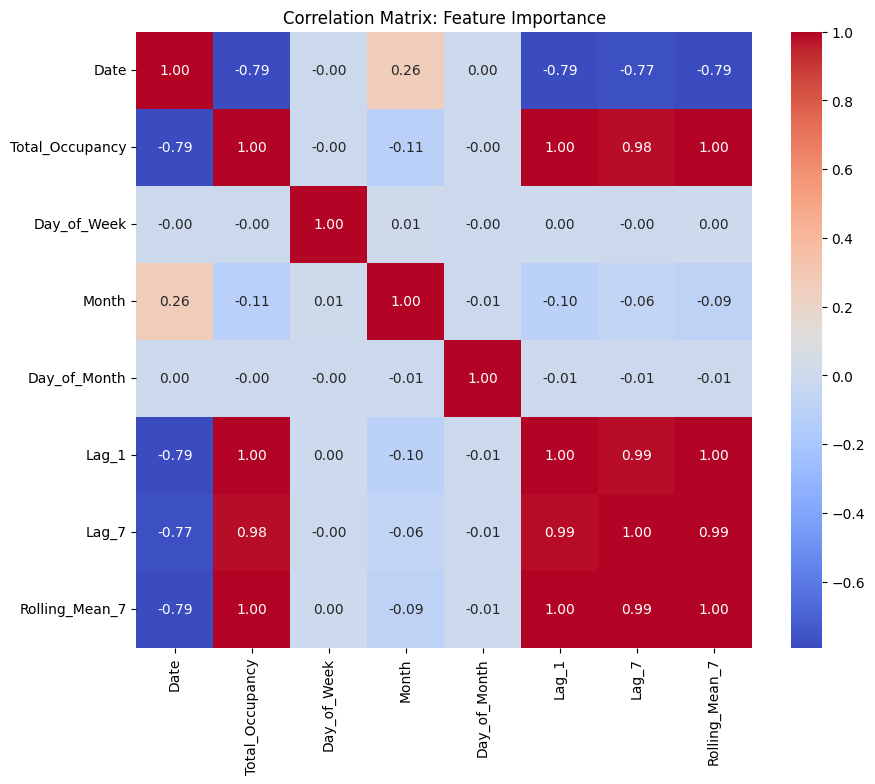

In [104]:
 
plt.figure(figsize=(10, 8))
sns.heatmap(df_ml.corr(), annot=True, cmap='coolwarm', fmt='.2f' ,square=True)
plt.title('Correlation Matrix: Feature Importance')
plt.show()


In [105]:
df_ml.to_csv('final_ml_data.csv', index=False)
print('final_ml_data.csv'  )

final_ml_data.csv


# Machine learning part

# Random forest

In [106]:
df=pd.read_csv('final_ml_data.csv')

In [107]:
df.head()

,Date,Total_Occupancy,Day_of_Week,Month,Day_of_Month,Lag_1,Lag_7,Rolling_Mean_7
0,2017-01-11,145,2,1,11,127.0,23.0,98.285714
1,2017-01-12,158,3,1,12,145.0,50.0,113.714286
2,2017-01-13,158,4,1,13,158.0,69.0,126.428571
3,2017-01-14,158,5,1,14,158.0,79.0,137.714286
4,2017-01-15,158,6,1,15,158.0,102.0,145.714286


In [108]:
x = df.drop(['Total_Occupancy', 'Date'], axis=1) 
 
y = df['Total_Occupancy']

In [109]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [110]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(x_train, y_train) 


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [111]:
y_pred = model.predict(x_test)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [112]:
 
print(" Result of Random Forest ")
print(f"Accuracy (R² Score): {r2:.2f}")
print(f"Average Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")

 Result of Random Forest 
Accuracy (R² Score): 1.00
Average Error (MAE): 5.23
Mean Squared Error (MSE): 80.75


  # linear Regression

In [113]:
from sklearn.linear_model import  LinearRegression

In [114]:
model= LinearRegression()
model.fit(x_train, y_train)
 


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [115]:
y_pred= model.predict(x_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [116]:
print(" Result of Linear Regression ")
print(f"Accuracy (R² Score): {r2:.2f}")
print(f"Average Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")

 Result of Linear Regression 
Accuracy (R² Score): 1.00
Average Error (MAE): 4.93
Mean Squared Error (MSE): 53.91


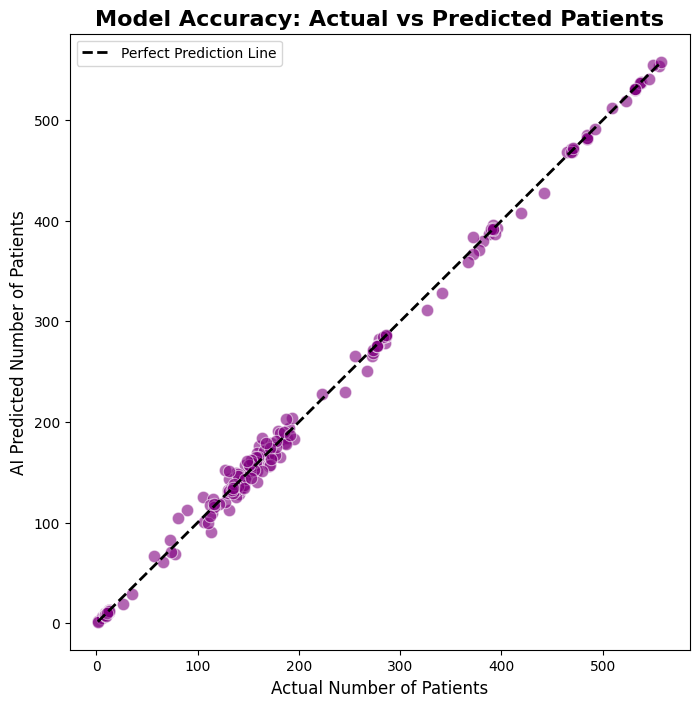

In [117]:
 

plt.figure(figsize=(8, 8))
 
sns.scatterplot(x=y_test, y=y_pred, color='purple', alpha=0.6, s=80)

 
max_val = max(max(y_test), max(y_pred))
min_val = min(min(y_test), min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=2, label='Perfect Prediction Line')

plt.title('Model Accuracy: Actual vs Predicted Patients', fontsize=16, fontweight='bold')
plt.xlabel('Actual Number of Patients', fontsize=12)
plt.ylabel('AI Predicted Number of Patients', fontsize=12)
plt.legend()
plt.show()

 # GradientBoostingRegressor

In [118]:
from sklearn.ensemble import GradientBoostingRegressor
 

 

In [119]:

gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(x_train, y_train)


,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [120]:
y_pred_gb = gb_model.predict(x_test)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

In [121]:
print(" Result of Gradient Boosting ")
 
print(f"Accuracy (R² Score): {r2_gb:.2f}")
print(f"Average Error (MAE): {mae_gb:.2f}")
print(f"Mean Squared Error (MSE): {mse_gb:.2f}")

 Result of Gradient Boosting 
Accuracy (R² Score): 1.00
Average Error (MAE): 5.23
Mean Squared Error (MSE): 67.50


#  Model Comparison: Which model performed best

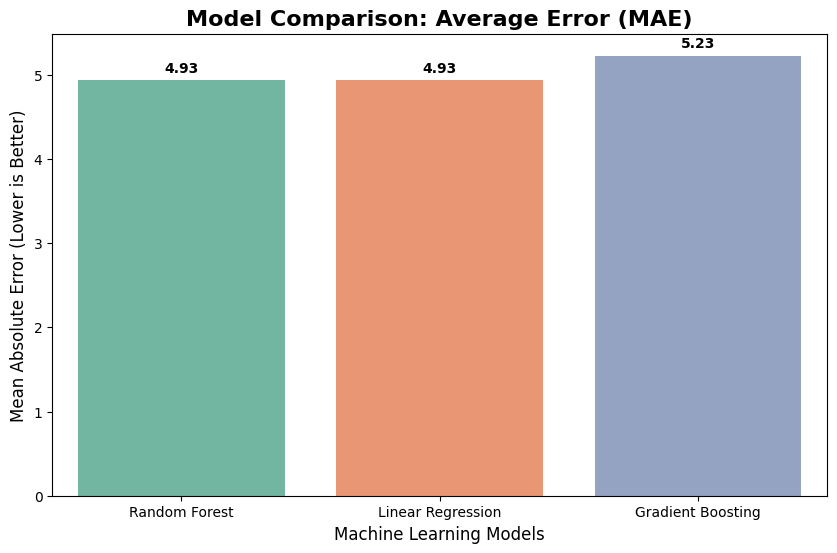

In [122]:
 
import matplotlib.pyplot as plt
import seaborn as sns
models = ['Random Forest', 'Linear Regression', 'Gradient Boosting']
mae_scores = [mae, mean_absolute_error(y_test, model.predict(x_test)), mae_gb]  
plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=mae_scores, palette='Set2')
plt.title('Model Comparison: Average Error (MAE)', fontsize=16, fontweight='bold')
plt.xlabel('Machine Learning Models', fontsize=12)
plt.ylabel('Mean Absolute Error (Lower is Better)', fontsize=12)

for i, v in enumerate(mae_scores):
    plt.text(i, v + 0.1, f"{v:.2f}", color='black', ha='center', fontweight='bold')

plt.show()

# Feature Importance: Which clues helped the AI most?

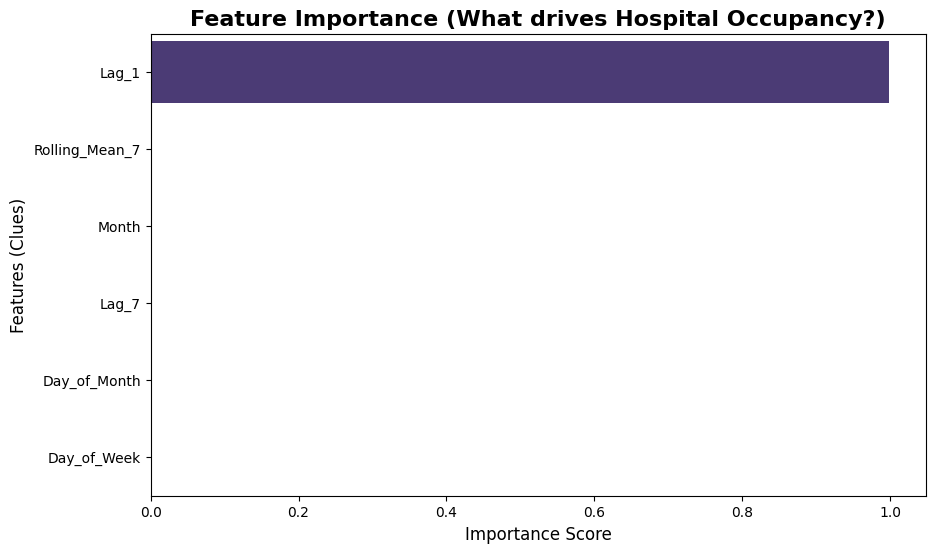

In [123]:
 
import numpy as np
 
feature_importance = gb_model.feature_importances_
feature_names = x.columns
 
indices = np.argsort(feature_importance)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance[indices], y=feature_names[indices], palette='viridis')

plt.title('Feature Importance (What drives Hospital Occupancy?)', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features (Clues)', fontsize=12)
plt.show()

# Real-time Trend: Actual vs Predicted over Time

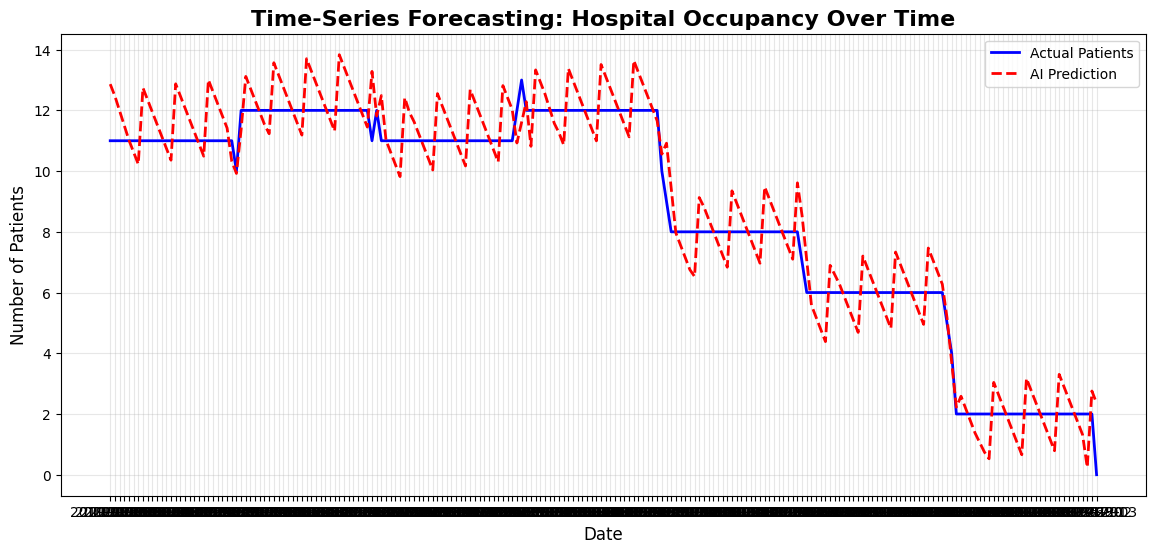

In [124]:
 
split_idx = int(len(x) * 0.8)
x_train_seq, x_test_seq = x.iloc[:split_idx], x.iloc[split_idx:]
y_train_seq, y_test_seq = y.iloc[:split_idx], y.iloc[split_idx:]
dates_test = df['Date'].iloc[split_idx:]  

 
best_model.fit(x_train_seq, y_train_seq)
y_pred_seq = best_model.predict(x_test_seq)

plt.figure(figsize=(14, 6))
 
plt.plot(dates_test, y_test_seq, label='Actual Patients', color='blue', linewidth=2)
 
plt.plot(dates_test, y_pred_seq, label='AI Prediction', color='red', linestyle='--', linewidth=2)

plt.title('Time-Series Forecasting: Hospital Occupancy Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

# 🚨 AI-Based Early Warning System Dashboard

In [125]:
 

#  use for last row of data for prediction
latest_data = x_test_seq.iloc[-1:] 

#  convert string to datetime and format it
latest_date_raw = dates_test.iloc[-1]
latest_date = pd.to_datetime(latest_date_raw).strftime('%d %B, %Y')

# use our best model (Linear Regression) to predict the number of patients for the next day
predicted_occupancy = int(best_model.predict(latest_data)[0])

#  use for sample hospital bed capacity and alert threshold
TOTAL_BEDS = 500           
WARNING_THRESHOLD = 450     

print("=" * 55)
print("🏥 HOSPITAL EARLY WARNING DASHBOARD 🏥")
print("=" * 55)
print(f"📅 Date (Forecast)  : {latest_date}")
print(f"🛏️ Total Capacity   : {TOTAL_BEDS} Beds")
print(f"📊 Expected Patients: {predicted_occupancy} Patients")
print("-" * 55)

#  AI Alert Logic
if predicted_occupancy >= TOTAL_BEDS:
    print("🚨 [CRITICAL ALERT]: Hospital is at OVERCAPACITY!")
    print("👉 Action: Stop new regular admissions. Prepare emergency floor beds.")

elif predicted_occupancy >= WARNING_THRESHOLD:
    print("⚠️ [WARNING]: High patient volume detected! (Over 90% Booked)")
    print("👉 Action: Keep emergency staff on standby. Fast-track patient discharges.")

else:
    print("✅ [STATUS NORMAL]: Sufficient beds are available.")
    print("👉 Action: Continue normal hospital operations.")

print("=" * 55)

🏥 HOSPITAL EARLY WARNING DASHBOARD 🏥
📅 Date (Forecast)  : 03 December, 2019
🛏️ Total Capacity   : 500 Beds
📊 Expected Patients: 2 Patients
-------------------------------------------------------
✅ [STATUS NORMAL]: Sufficient beds are available.
👉 Action: Continue normal hospital operations.


In [126]:
 
row_number = -10  
 
latest_data = x_test_seq.iloc[row_number : row_number+1].copy() 
latest_date_raw = dates_test.iloc[row_number]
latest_date = pd.to_datetime(latest_date_raw).strftime('%d %B, %Y')

 
latest_data['Lag_1'] = 465  
latest_data['Rolling_Mean_7'] = 460 

 
predicted_occupancy = int(best_model.predict(latest_data)[0])

TOTAL_BEDS = 500            
WARNING_THRESHOLD = 450    

print("=" * 55)
print("🏥 HOSPITAL EARLY WARNING DASHBOARD 🏥")
print("=" * 55)
print(f"📅 Date (Forecast)  : {latest_date}")
print(f"🛏️ Total Capacity   : {TOTAL_BEDS} Beds")
print(f"📊 Expected Patients: {predicted_occupancy} Patients")
print("-" * 55)

if predicted_occupancy >= TOTAL_BEDS:
    print("🚨 [CRITICAL ALERT]: Hospital is at OVERCAPACITY!")
    print("👉 Action: Stop new regular admissions. Prepare emergency floor beds.")

elif predicted_occupancy >= WARNING_THRESHOLD:
    print("⚠️ [WARNING]: High patient volume detected! (Over 90% Booked)")
    print("👉 Action: Keep emergency staff on standby. Fast-track patient discharges.")

else:
    print("✅ [STATUS NORMAL]: Sufficient beds are available.")
    print("👉 Action: Continue normal hospital operations.")

print("=" * 55)

🏥 HOSPITAL EARLY WARNING DASHBOARD 🏥
📅 Date (Forecast)  : 24 November, 2019
🛏️ Total Capacity   : 500 Beds
📊 Expected Patients: 503 Patients
-------------------------------------------------------
🚨 [CRITICAL ALERT]: Hospital is at OVERCAPACITY!
👉 Action: Stop new regular admissions. Prepare emergency floor beds.
